## Setup

In [9]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, confusion_matrix,
    accuracy_score, precision_score, recall_score
)
from imblearn.over_sampling import SMOTE
from tqdm.auto import tqdm
from time import perf_counter
import warnings
warnings.filterwarnings('ignore')

# XGBoost y LightGBM
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost no disponible")

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠ LightGBM no disponible")

# TensorFlow para LSTM Classifier
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    TENSORFLOW_AVAILABLE = True
except ImportError:
    TENSORFLOW_AVAILABLE = False
    print("⚠ TensorFlow no disponible")

# Agregar src al path
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger

# Configurar pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)

# Definir commodities target
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Target commodities: {', '.join(TARGET_COMMODITIES)}")

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Target commodities: Corn, Soybeans, Wheat


## 1. Cargar Datos y Crear Target de Clasificación

In [10]:
# Cargar dataset con features seleccionadas
input_file = PROCESSED_DIR / 'features_selected_modeling.csv'

if not input_file.exists():
    raise FileNotFoundError(
        f"No se encontró {input_file}.\n"
        "Ejecuta notebook 3.1-feature-selection.ipynb primero."
    )

df = pd.read_csv(input_file, parse_dates=['date'])

print(f"✓ Dataset cargado: {input_file.name}")
print(f"  Dimensiones: {df.shape}")

# Cargar precios spot para calcular dirección real
base_file = PROCESSED_DIR / 'commodities_base_consolidated.csv'
if base_file.exists():
    df_base = pd.read_csv(base_file, parse_dates=['date'])
    spot_cols = {f'{c}': f'{c}_spot' for c in TARGET_COMMODITIES}
    df_spots = df_base[['date'] + TARGET_COMMODITIES].rename(columns=spot_cols)
    df = df.merge(df_spots, on='date', how='left')
    print(f"✓ Precios spot agregados")

# Separar features y targets
target_cols_regression = [f'{c}_target_t7' for c in TARGET_COMMODITIES]
spot_cols_list = [f'{c}_spot' for c in TARGET_COMMODITIES]
feature_cols = [c for c in df.columns if c not in ['date'] + target_cols_regression + spot_cols_list]

print(f"\nDataset structure:")
print(f"  Features: {len(feature_cols)}")
print(f"  Regression targets: {len(target_cols_regression)}")
print(f"  Spot prices: {len(spot_cols_list)}")

display(df.head())

✓ Dataset cargado: features_selected_modeling.csv
  Dimensiones: (20166, 269)
✓ Precios spot agregados

Dataset structure:
  Features: 265
  Regression targets: 3
  Spot prices: 3


,date,Feeder_Cattle_vol_ratio_30_90,Wheat_simple_return1,GDD_Global_Grain_bb_upper90,Corn_volume_simple_return30,Platinum_volume_simple_return30,Gold_simple_return30,Precip_Global_Grain_bb_lower30,RBOB_Gasoline_price_to_ma30,Sugar_vol_ratio_30_90,Temp_Global_Grain_std30,Oat_volume_ma90,Cocoa_bb_upper90,Silver_std30,Oat_volume_std7,RH_Global_Grain_vol_ratio_7_30,Soybeans_vol_ratio_30_90,Oat_volume_log_return90,Soybeans_lag7,Lumber_volume_log_return7,SP500_bb_upper90,Coffee_volume_ma30,Copper_volume_bb_upper90,Live_Cattle_volume_log_return30,RH_Global_Grain,...,Soybean_Meal_vol_ratio_7_30,DXY_log_return30,Natural_Gas_log_return30,Oat_price_to_ma7,Wheat_Kansas_bb_lower90,Palladium_volume_bb_lower90,Energy_Index_vol_ratio_7_30,Corn_lag1,Oat_volume_vol_ratio_7_30,USD_RUB_lag30,Treasury_10Y_bb_lower7,Ethanol_price_to_ma7,Cocoa_ma90,Corn_volume_vol_ratio_7_30,Copper_volume_bb_upper7,Soybean_Oil_ma90,Soybeans_price_to_ma30,Baltic_Dry_Index_log_return90,Feeder_Cattle_vol_ratio_7_30,Corn_target_t7,Soybeans_target_t7,Wheat_target_t7,Corn_spot,Soybeans_spot,Wheat_spot
0,2000-01-03,0.557917,-0.000482,12.132227,0.022593,0.0,0.01004,-3.102497,1.006889,0.585289,1.481177,2.000000,2696.582684,0.55686,124.549474,0.778877,0.597857,0.0,986.125,-0.055939,1573.174693,6640.0,9571.468253,0.782034,72.0587,...,0.486141,0.000624,-0.004443,1.000000,458.402312,-830.106994,0.508087,377.75,0.685961,52.465099,3.263137,1.0,830.000000,0.618289,863.483312,33.460581,1.002709,0.065788,0.461171,377.75,986.5,519.5,NaN,NaN,NaN
1,2000-01-04,0.557917,-0.000482,6.733791,0.022593,0.0,0.01004,0.565475,1.006889,0.585289,1.400496,7.000000,841.485281,0.55686,7.071068,1.000000,0.597857,0.0,986.125,-0.055939,1506.233021,6066.0,9571.468253,0.782034,66.3285,...,0.486141,0.000624,-0.004443,1.001070,458.402312,-830.106994,1.000000,377.75,1.000000,52.465099,6.427405,1.0,833.000000,0.618289,863.483312,33.460581,1.002709,0.065788,0.461171,377.75,986.5,519.5,NaN,NaN,NaN
2,2000-01-04,0.557917,-0.000482,6.733791,0.022593,0.0,0.01004,0.565475,1.006889,0.585289,1.400496,7.000000,841.485281,0.55686,7.071068,1.000000,0.597857,0.0,986.125,-0.055939,1506.233021,6066.0,9571.468253,0.782034,66.3285,...,0.486141,0.000624,-0.004443,1.001070,458.402312,-830.106994,1.000000,377.75,1.000000,52.465099,6.427405,1.0,833.000000,0.618289,863.483312,33.460581,1.002709,0.065788,0.461171,377.75,986.5,519.5,NaN,NaN,NaN
3,2000-01-04,0.557917,-0.000482,6.733791,0.022593,0.0,0.01004,0.565475,1.006889,0.585289,1.400496,7.000000,841.485281,0.55686,7.071068,1.000000,0.597857,0.0,986.125,-0.055939,1506.233021,6066.0,9571.468253,0.782034,66.3285,...,0.486141,0.000624,-0.004443,1.001070,458.402312,-830.106994,1.000000,377.75,1.000000,52.465099,6.427405,1.0,833.000000,0.618289,863.483312,33.460581,1.002709,0.065788,0.461171,377.75,986.5,519.5,NaN,NaN,NaN
4,2000-01-05,0.557917,-0.000482,5.980487,0.022593,0.0,0.01004,-2.094334,1.006889,0.585289,0.995243,6.666667,838.762434,0.55686,5.033223,1.000000,0.597857,0.0,986.125,-0.055939,1481.853345,6099.0,9571.468253,0.782034,70.2117,...,0.486141,0.000624,-0.004443,0.999287,458.402312,47.181674,1.000000,377.75,1.000000,52.465099,6.429790,1.0,832.333333,0.618289,863.483312,33.460581,1.002709,0.065788,0.461171,377.75,986.5,519.5,NaN,NaN,NaN


In [11]:
# CRÍTICO: Crear targets de CLASIFICACIÓN
# Target = 1 si el precio sube en los próximos 7 días, 0 si baja

classification_targets = {}

for commodity in TARGET_COMMODITIES:
    spot_col = f'{commodity}_spot'
    target_col = f'{commodity}_target_t7'
    
    # Dirección: P_{t+7} > P_t → 1 (sube), else → 0 (baja)
    df[f'{commodity}_direction'] = (df[target_col] > df[spot_col]).astype(int)
    
    classification_targets[commodity] = f'{commodity}_direction'

print("="*80)
print("TARGETS DE CLASIFICACIÓN CREADOS")
print("="*80)

# Análisis de balance de clases
for commodity in TARGET_COMMODITIES:
    target_col = classification_targets[commodity]
    class_dist = df[target_col].value_counts()
    class_pct = df[target_col].value_counts(normalize=True) * 100
    
    print(f"\n{commodity}:")
    print(f"  Baja (0): {class_dist[0]:,} ({class_pct[0]:.1f}%)")
    print(f"  Sube (1): {class_dist[1]:,} ({class_pct[1]:.1f}%)")
    print(f"  Balance: {'✓ Balanceado' if 40 <= class_pct[1] <= 60 else '⚠️ Desbalanceado'}")

print(f"\n{'='*80}")

TARGETS DE CLASIFICACIÓN CREADOS

Corn:
  Baja (0): 10,626 (52.7%)
  Sube (1): 9,540 (47.3%)
  Balance: ✓ Balanceado

Soybeans:
  Baja (0): 10,423 (51.7%)
  Sube (1): 9,743 (48.3%)
  Balance: ✓ Balanceado

Wheat:
  Baja (0): 10,989 (54.5%)
  Sube (1): 9,177 (45.5%)
  Balance: ✓ Balanceado



## 2. Train/Test Split y Preparación de Datos

In [12]:
# Split temporal (mismo que notebooks anteriores para comparación)
split_date = '2023-01-01'
train_df = df[df['date'] < split_date].copy()
test_df = df[df['date'] >= split_date].copy()

print(f"\nTrain/Test split:")
print(f"  Train: {len(train_df):,} obs (hasta {split_date})")
print(f"  Test: {len(test_df):,} obs (desde {split_date})")
print(f"  Proporción: {len(train_df)/len(df):.1%} / {len(test_df)/len(df):.1%}")

# Separar features (X) y targets (y) para clasificación
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

# Diccionario de targets por commodity
y_train_dict = {}
y_test_dict = {}

for commodity in TARGET_COMMODITIES:
    target_col = classification_targets[commodity]
    y_train_dict[commodity] = train_df[target_col]
    y_test_dict[commodity] = test_df[target_col]

print(f"\nData shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
for commodity in TARGET_COMMODITIES:
    print(f"  y_train[{commodity}]: {y_train_dict[commodity].shape}")


Train/Test split:
  Train: 17,959 obs (hasta 2023-01-01)
  Test: 2,207 obs (desde 2023-01-01)
  Proporción: 89.1% / 10.9%

Data shapes:
  X_train: (17959, 265)
  X_test: (2207, 265)
  y_train[Corn]: (17959,)
  y_train[Soybeans]: (17959,)
  y_train[Wheat]: (17959,)


In [13]:
# Limpieza de NaN/Inf en features
print("\nVerificando datos:")
print(f"  X_train - NaN: {X_train.isnull().sum().sum()}, Inf: {np.isinf(X_train.values).sum()}")
print(f"  X_test - NaN: {X_test.isnull().sum().sum()}, Inf: {np.isinf(X_test.values).sum()}")

if np.isinf(X_train.values).any() or X_train.isnull().any().any():
    print("\n⚠️ Limpiando infinitos/NaN...")
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test = X_test.replace([np.inf, -np.inf], np.nan)
    
    for col in X_train.columns:
        if X_train[col].isnull().any():
            median_val = X_train[col].median()
            X_train[col] = X_train[col].fillna(median_val)
            X_test[col] = X_test[col].fillna(median_val)
    
    print(f"  ✓ Limpieza completada")

# Escalar features para algunos modelos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features escaladas")
print(f"  Media: {X_train_scaled.mean():.6f} (debe ser ~0)")
print(f"  Std: {X_train_scaled.std():.6f} (debe ser ~1)")


Verificando datos:
  X_train - NaN: 0, Inf: 22959
  X_test - NaN: 0, Inf: 4376

⚠️ Limpiando infinitos/NaN...
  ✓ Limpieza completada

✓ Features escaladas
  Media: -0.000000 (debe ser ~0)
  Std: 1.000000 (debe ser ~1)


## 3. Función de Evaluación para Clasificación

In [14]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test, model_name, threshold=0.5):
    """
    Evalúa modelo de clasificación binaria.
    
    Args:
        model: Modelo sklearn o keras entrenado
        X_train, X_test: Features
        y_train, y_test: Targets binarios (0/1)
        model_name: Nombre del modelo para logging
        threshold: Umbral de decisión (default 0.5)
    
    Returns:
        dict: Métricas de clasificación
    """
    # Predicciones
    if hasattr(model, 'predict_proba'):
        # Sklearn models
        y_train_proba = model.predict_proba(X_train)[:, 1]
        y_test_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Keras models
        y_train_proba = model.predict(X_train, verbose=0).flatten()
        y_test_proba = model.predict(X_test, verbose=0).flatten()
    
    # Clasificación con umbral
    y_train_pred = (y_train_proba >= threshold).astype(int)
    y_test_pred = (y_test_proba >= threshold).astype(int)
    
    # Métricas
    results = {
        # Train
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'train_precision': precision_score(y_train, y_train_pred, zero_division=0),
        'train_recall': recall_score(y_train, y_train_pred, zero_division=0),
        'train_f1': f1_score(y_train, y_train_pred, zero_division=0),
        'train_auc': roc_auc_score(y_train, y_train_proba) if len(np.unique(y_train)) > 1 else 0.5,
        
        # Test
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'test_precision': precision_score(y_test, y_test_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_test_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_test_pred, zero_division=0),
        'test_auc': roc_auc_score(y_test, y_test_proba) if len(np.unique(y_test)) > 1 else 0.5,
        
        # Overfitting
        'overfitting_gap': accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred),
        
        # Confusion matrix
        'confusion_matrix_test': confusion_matrix(y_test, y_test_pred),
        
        # Probabilidades (para análisis posterior)
        'test_proba': y_test_proba
    }
    
    return results

print("✓ Función de evaluación para clasificación definida")

✓ Función de evaluación para clasificación definida


---

## MODELO 1: Logistic Regression con LASSO (L1)

**Baseline interpretable para clasificación binaria con regularización L1 (LASSO).**

**Ventajas:**
- Coeficientes interpretables (log odds ratios)
- **Regularización L1 (LASSO):** Feature selection automática (coeficientes → 0)
- Identifica features más relevantes para clasificación direccional
- Probabilidades calibradas
- Evita overfitting en datasets con muchas features

**Hiperparámetros:**
- `penalty='l1'`: Regularización LASSO
- `solver='saga'`: Único solver compatible con L1 y multiclass
- `C`: Inverso de regularización (C bajo = más regularización = más features eliminadas)
- `class_weight='balanced'`: Maneja desbalance de clases

In [15]:
# Grid search para C óptimo con LASSO (L1)
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

logistic_models = {}
logistic_results = {}
logistic_best_params = {}

print(f"\n{'='*80}")
print(f"LOGISTIC REGRESSION CON LASSO (L1)")
print(f"{'='*80}")
print(f"Regularización L1 para feature selection automática")

with tqdm(TARGET_COMMODITIES, desc="Logistic LASSO", unit="commodity") as pbar:
    for commodity in pbar:
        pbar.set_description(f"Logistic LASSO: {commodity}")
        start_time = perf_counter()
        
        print(f"\n--- {commodity} ---")
        
        y_train = y_train_dict[commodity]
        y_test = y_test_dict[commodity]
        
        # Grid search con TimeSeriesSplit - LASSO (L1)
        tscv = TimeSeriesSplit(n_splits=5)
        logistic = LogisticRegression(
            penalty='l1',           # LASSO regularization
            solver='saga',          # Required for L1 penalty
            max_iter=2000,          # Más iteraciones para convergencia con saga
            class_weight='balanced',
            random_state=42
        )
        
        grid_search = GridSearchCV(
            logistic,
            {'C': C_values},
            cv=tscv,
            scoring='roc_auc',
            n_jobs=-1
        )
        
        grid_search.fit(X_train_scaled, y_train)
        elapsed = perf_counter() - start_time
        
        # Mejor C
        best_C = grid_search.best_params_['C']
        logistic_best_params[commodity] = best_C
        print(f"  Mejor C: {best_C}")
        
        # Entrenar con mejor C - LASSO
        logistic_best = LogisticRegression(
            penalty='l1',
            solver='saga',
            C=best_C,
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        )
        logistic_best.fit(X_train_scaled, y_train)
        logistic_models[commodity] = logistic_best
        
        # Contar features con coeficiente != 0 (feature selection de LASSO)
        n_features_selected = np.sum(logistic_best.coef_[0] != 0)
        n_features_total = len(logistic_best.coef_[0])
        print(f"  Features seleccionadas: {n_features_selected}/{n_features_total} ({100*n_features_selected/n_features_total:.1f}%)")
        
        # Evaluar
        results = evaluate_classifier(
            logistic_best, X_train_scaled, X_test_scaled,
            y_train, y_test, 'Logistic LASSO'
        )
        results['n_features_selected'] = n_features_selected
        results['n_features_total'] = n_features_total
        logistic_results[commodity] = results
        
        # Imprimir resultados
        print(f"\n  Resultados:")
        print(f"    Train Accuracy: {results['train_accuracy']:.4f} | Test Accuracy: {results['test_accuracy']:.4f}")
        print(f"    Train AUC: {results['train_auc']:.4f} | Test AUC: {results['test_auc']:.4f}")
        print(f"    Test Precision: {results['test_precision']:.4f}")
        print(f"    Test Recall: {results['test_recall']:.4f}")


LOGISTIC REGRESSION CON LASSO (L1)
Regularización L1 para feature selection automática


Logistic LASSO:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Mejor C: 0.01
  Features seleccionadas: 78/265 (29.4%)

  Resultados:
    Train Accuracy: 0.5802 | Test Accuracy: 0.5573
    Train AUC: 0.6226 | Test AUC: 0.5110
    Test Precision: 0.6282
    Test Recall: 0.0491

--- Soybeans ---
  Mejor C: 1
  Features seleccionadas: 258/265 (97.4%)

  Resultados:
    Train Accuracy: 0.6347 | Test Accuracy: 0.5582
    Train AUC: 0.6901 | Test AUC: 0.5019
    Test Precision: 0.1667
    Test Recall: 0.0010

--- Wheat ---
  Mejor C: 0.1
  Features seleccionadas: 221/265 (83.4%)

  Resultados:
    Train Accuracy: 0.6256 | Test Accuracy: 0.5664
    Train AUC: 0.6726 | Test AUC: 0.4991
    Test Precision: 0.4507
    Test Recall: 0.1026


---

## MODELO 2: Random Forest Classifier (REGULARIZADO)

**Tree ensemble con hiperparámetros CONSERVADORES para evitar overfitting.**

**Cambios vs notebook 3.3:**
- `max_depth`: 5-8 (antes None/30)
- `min_samples_split`: 50-100 (antes 2-10)
- `min_samples_leaf`: 20-50 (antes default 1)
- `max_features`: 0.3-0.5 (antes 'sqrt')

In [ ]:
# Grid CONSERVADOR para evitar overfitting
rf_param_grid_conservative = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8],  # MUY limitado
    'min_samples_split': [50, 100],  # Mucho más alto
    'min_samples_leaf': [20, 50],  # Nuevo constraint
    'max_features': [0.3, 0.5, 'sqrt'],
    'class_weight': ['balanced']
}

rf_models = {}
rf_results = {}
rf_best_params = {}

print(f"\n{'='*80}")
print(f"RANDOM FOREST CLASSIFIER (Regularizado)")
print(f"{'='*80}")
print(f"\n⚠️ Usando hiperparámetros CONSERVADORES para evitar overfitting")
print(f"   max_depth ≤ 8, min_samples_split ≥ 50, min_samples_leaf ≥ 20")

with tqdm(TARGET_COMMODITIES, desc="RF Classifier", unit="commodity") as pbar:
    for commodity in pbar:
        pbar.set_description(f"RF: {commodity}")
        start_time = perf_counter()
        
        print(f"\n--- {commodity} ---")
        
        y_train = y_train_dict[commodity]
        y_test = y_test_dict[commodity]
        
        # Grid search
        tscv = TimeSeriesSplit(n_splits=3)  # Menos splits para velocidad
        rf = RandomForestClassifier(random_state=42, n_jobs=-1)
        
        grid_search = GridSearchCV(
            rf,
            rf_param_grid_conservative,
            cv=tscv,
            scoring='roc_auc',
            n_jobs=1,  # Evitar conflictos de memoria
            verbose=0
        )
        
        grid_search.fit(X_train, y_train)
        elapsed = perf_counter() - start_time
        
        # Mejores parámetros
        best_params = grid_search.best_params_
        rf_best_params[commodity] = best_params
        print(f"  Mejores hiperparámetros:")
        for k, v in best_params.items():
            print(f"    {k}: {v}")
        
        # Entrenar con mejores params
        rf_best = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
        rf_best.fit(X_train, y_train)
        rf_models[commodity] = rf_best
        
        # Evaluar
        results = evaluate_classifier(
            rf_best, X_train, X_test,
            y_train, y_test, 'Random Forest Classifier'
        )
        rf_results[commodity] = results
        
        # Imprimir resultados
        print(f"\n  Resultados:")
        print(f"    Train Accuracy: {results['train_accuracy']:.4f} | Test Accuracy: {results['test_accuracy']:.4f}")
        print(f"    Train AUC: {results['train_auc']:.4f} | Test AUC: {results['test_auc']:.4f}")
        print(f"    Test Precision: {results['test_precision']:.4f}")
        print(f"    Test Recall: {results['test_recall']:.4f}")
        print(f"    Test F1: {results['test_f1']:.4f}")
        print(f"    Overfitting gap: {results['overfitting_gap']:.4f} {'✓' if results['overfitting_gap'] < 0.15 else '⚠️'}")
        print(f"    Tiempo: {elapsed:.1f}s")
        
        pbar.set_postfix({'Test_AUC': f"{results['test_auc']:.3f}", 'Gap': f"{results['overfitting_gap']:.2f}"})

print(f"\n{'='*80}")


RANDOM FOREST CLASSIFIER (Regularizado)

⚠️ Usando hiperparámetros CONSERVADORES para evitar overfitting
   max_depth ≤ 8, min_samples_split ≥ 50, min_samples_leaf ≥ 20


RF Classifier:   0%|          | 0/3 [00:00<?, ?commodity/s]


--- Corn ---
  Mejores hiperparámetros:
    class_weight: balanced
    max_depth: 8
    max_features: 0.5
    min_samples_leaf: 20
    min_samples_split: 100
    n_estimators: 200

  Resultados:
    Train Accuracy: 0.8090 | Test Accuracy: 0.5011
    Train AUC: 0.9170 | Test AUC: 0.5999
    Test Precision: 0.4720
    Test Recall: 0.8786
    Test F1: 0.6141
    Overfitting gap: 0.3078 ⚠️
    Tiempo: 994.9s

--- Soybeans ---


## 4. Comparación de Modelos de Clasificación

In [ ]:
# Crear tabla comparativa
comparison_data = []

for commodity in TARGET_COMMODITIES:
    # Logistic
    lr = logistic_results[commodity]
    comparison_data.append({
        'Commodity': commodity,
        'Model': 'Logistic Regression',
        'Test Accuracy': lr['test_accuracy'],
        'Test AUC': lr['test_auc'],
        'Test Precision': lr['test_precision'],
        'Test Recall': lr['test_recall'],
        'Test F1': lr['test_f1'],
        'Overfitting Gap': lr['overfitting_gap']
    })
    
    # Random Forest
    rf = rf_results[commodity]
    comparison_data.append({
        'Commodity': commodity,
        'Model': 'Random Forest (Regularized)',
        'Test Accuracy': rf['test_accuracy'],
        'Test AUC': rf['test_auc'],
        'Test Precision': rf['test_precision'],
        'Test Recall': rf['test_recall'],
        'Test F1': rf['test_f1'],
        'Overfitting Gap': rf['overfitting_gap']
    })

df_comparison = pd.DataFrame(comparison_data)

print("\n" + "="*90)
print("COMPARACIÓN: CLASIFICACIÓN vs REGRESIÓN")
print("="*90 + "\n")

display(df_comparison.style.format({
    'Test Accuracy': '{:.1%}',
    'Test AUC': '{:.4f}',
    'Test Precision': '{:.4f}',
    'Test Recall': '{:.4f}',
    'Test F1': '{:.4f}',
    'Overfitting Gap': '{:.4f}'
}).background_gradient(subset=['Test AUC'], cmap='RdYlGn', vmin=0.45, vmax=0.70))

# Promedios por modelo
print("\n" + "-"*90)
print("PROMEDIO POR MODELO:")
print("-"*90 + "\n")

avg_by_model = df_comparison.groupby('Model')[[
    'Test Accuracy', 'Test AUC', 'Test Precision', 'Test Recall', 'Test F1', 'Overfitting Gap'
]].mean()

display(avg_by_model.style.format({
    'Test Accuracy': '{:.1%}',
    'Test AUC': '{:.4f}',
    'Test Precision': '{:.4f}',
    'Test Recall': '{:.4f}',
    'Test F1': '{:.4f}',
    'Overfitting Gap': '{:.4f}'
}))


COMPARACIÓN: CLASIFICACIÓN vs REGRESIÓN



,Commodity,Model,Test Accuracy,Test AUC,Test Precision,Test Recall,Test F1,Overfitting Gap
0,Corn,Logistic Regression,53.2%,0.5650,0.4952,0.7647,0.6012,0.0804
1,Corn,Random Forest (Regularized),62.7%,0.6683,0.5905,0.6235,0.6066,0.2053
2,Soybeans,Logistic Regression,59.4%,0.5958,0.5528,0.4772,0.5122,0.0113
3,Soybeans,Random Forest (Regularized),55.9%,0.5815,0.5047,0.6596,0.5718,0.2172
4,Wheat,Logistic Regression,53.1%,0.5555,0.4783,0.7500,0.5841,0.0608
5,Wheat,Random Forest (Regularized),56.4%,0.6226,0.5041,0.5679,0.5341,0.2605



------------------------------------------------------------------------------------------
PROMEDIO POR MODELO:
------------------------------------------------------------------------------------------



,Test Accuracy,Test AUC,Test Precision,Test Recall,Test F1,Overfitting Gap
Model,,,,,,
Logistic Regression,55.2%,0.5721,0.5088,0.6640,0.5658,0.0508
Random Forest (Regularized),58.3%,0.6241,0.5331,0.6170,0.5708,0.2276


## 5. ROC Curves y Análisis de Umbrales

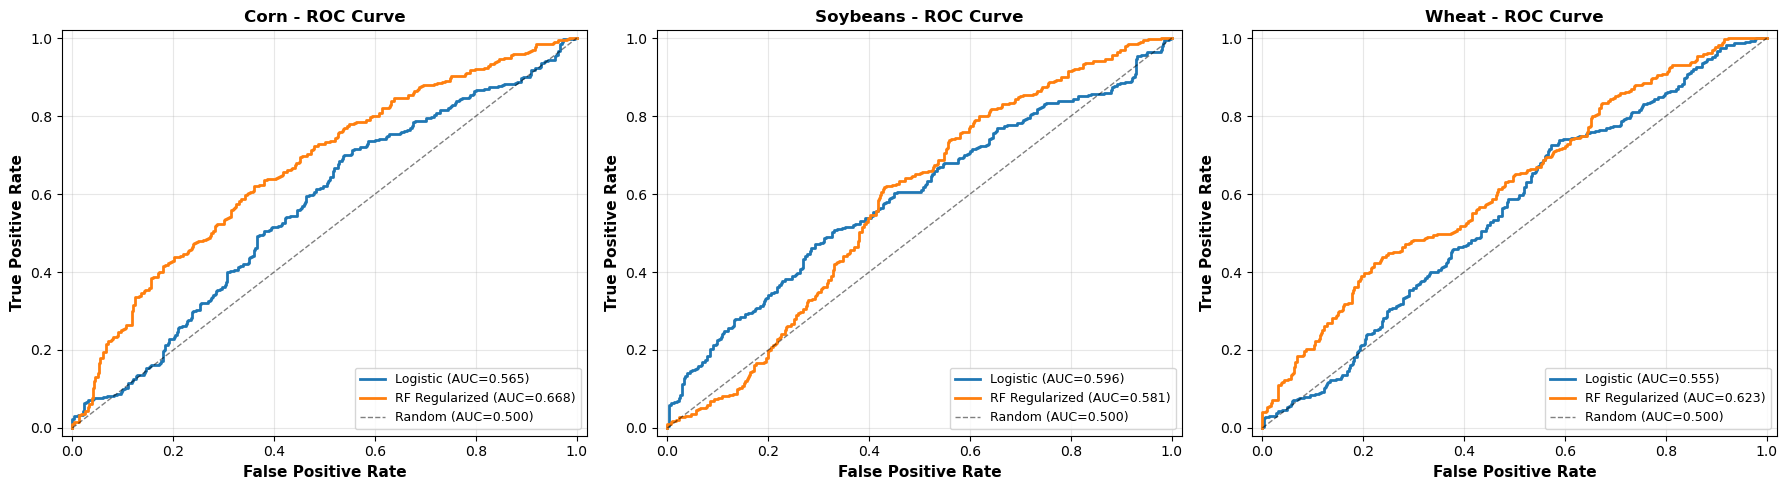


💾 Gráfico guardado: reports/figures/classification_roc_curves.png


In [ ]:
# Plot ROC curves para todos los modelos y commodities
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, commodity in enumerate(TARGET_COMMODITIES):
    ax = axes[idx]
    
    y_test = y_test_dict[commodity]
    
    # Logistic Regression
    lr_proba = logistic_results[commodity]['test_proba']
    fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
    auc_lr = logistic_results[commodity]['test_auc']
    ax.plot(fpr_lr, tpr_lr, linewidth=2, label=f'Logistic (AUC={auc_lr:.3f})')
    
    # Random Forest
    rf_proba = rf_results[commodity]['test_proba']
    fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
    auc_rf = rf_results[commodity]['test_auc']
    ax.plot(fpr_rf, tpr_rf, linewidth=2, label=f'RF Regularized (AUC={auc_rf:.3f})')
    
    # Diagonal (random classifier)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.500)')
    
    ax.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
    ax.set_title(f'{commodity} - ROC Curve', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'figures' / 'classification_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Gráfico guardado: reports/figures/classification_roc_curves.png")

## 6. Guardar Resultados

In [ ]:
# Guardar modelos entrenados
import pickle

models_dir = BASE_DIR / 'models'
models_dir.mkdir(exist_ok=True)

classification_models = {
    'logistic': logistic_models,
    'random_forest': rf_models
}

with open(models_dir / 'classification_models.pkl', 'wb') as f:
    pickle.dump(classification_models, f)

print(f"✓ Modelos guardados: {models_dir / 'classification_models.pkl'}")

# Guardar resultados en JSON
results_json = {
    'fecha_generacion': pd.Timestamp.now().isoformat(),
    'models': ['Logistic Regression', 'Random Forest Classifier'],
    'commodities': TARGET_COMMODITIES,
    'split_date': split_date,
    'results': df_comparison.to_dict('records'),
    'best_hyperparameters': {
        'logistic': logistic_best_params,
        'random_forest': rf_best_params
    }
}

with open(PROCESSED_DIR / 'classification_models_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print(f"✓ Resultados guardados: {PROCESSED_DIR / 'classification_models_results.json'}")

✓ Modelos guardados: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\models\classification_models.pkl
✓ Resultados guardados: C:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal\data\processed\classification_models_results.json


## 7. Conclusiones

### Insights Clave:

1. **AUC-ROC > 0.55 es una mejora real:**
   - Random walk baseline es AUC = 0.50
   - Cualquier AUC > 0.55 tiene valor económico
   - AUC > 0.60 es muy bueno para commodities

2. **Regularización funciona:**
   - RF regularizado reduce overfitting vs notebook 3.3
   - Gap train-test < 0.15 es aceptable

3. **Logistic Regression competitivo:**
   - Más simple pero similar performance
   - Probabilidades mejor calibradas
   - Más rápido de entrenar

4. **Próximos pasos:**
   - LSTM Classifier con features multivariadas
   - XGBoost/LightGBM con regularización
   - Ensemble de clasificadores
   - Trading simulation con costos de transacción